In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import datetime

In [2]:
df = pd.read_excel("Fraud.xlsx")
df.head()

,transaction_id,customer_id,transaction_date,amount,merchant_category,payment_method,location,is_fraud
0,1,1051,2026-01-04 01:39:00,1687.91,Electronics,credit_card,Chennai,0
1,2,1092,2026-01-05 18:01:00,942.19,Grocery,net_banking,Lucknow,0
2,3,1014,2026-01-02 23:05:00,484.81,Fuel,credit_card,Lucknow,0
3,4,1071,2026-01-01 11:22:00,4824.52,Grocery,net_banking,Delhi,0
4,5,1060,2026-01-02 03:48:00,4440.67,Electronics,upi,Lucknow,0


In [3]:
##### option a - drop the transaction_date column #####

# df.drop("transaction_date", axis=1, inplace=True)

In [4]:
##### option b - cyclical encoding #####

df['hour'] = df['transaction_date'].dt.hour
df['day_of_week'] = df['transaction_date'].dt.dayofweek



# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df = df.drop(columns=['transaction_date', 'hour', 'day_of_week'])

In [5]:
df.isnull().sum()
df.fillna(0, inplace=True)
df

,transaction_id,customer_id,amount,merchant_category,payment_method,location,is_fraud,hour_sin,hour_cos,dow_sin,dow_cos
0,1,1051,1687.91,Electronics,credit_card,Chennai,0,0.258819,9.659258e-01,-0.781831,0.623490
1,2,1092,942.19,Grocery,net_banking,Lucknow,0,-1.000000,-1.836970e-16,0.000000,1.000000
2,3,1014,484.81,Fuel,credit_card,Lucknow,0,-0.258819,9.659258e-01,-0.433884,-0.900969
3,4,1071,4824.52,Grocery,net_banking,Delhi,0,0.258819,-9.659258e-01,0.433884,-0.900969
4,5,1060,4440.67,Electronics,upi,Lucknow,0,0.707107,7.071068e-01,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...
995,996,1009,6932.19,Travel,upi,Chennai,0,0.258819,9.659258e-01,0.974928,-0.222521
996,997,1066,985.19,Fashion,upi,Delhi,0,1.000000,6.123234e-17,0.781831,0.623490
997,998,1017,5040.42,Travel,debit_card,Mumbai,0,1.000000,6.123234e-17,0.000000,1.000000
998,999,1099,1143.47,Fuel,wallet,Delhi,0,0.707107,7.071068e-01,0.433884,-0.900969


In [6]:
df = pd.get_dummies(df, drop_first=True)
df

,transaction_id,customer_id,amount,is_fraud,hour_sin,hour_cos,dow_sin,dow_cos,merchant_category_Fashion,merchant_category_Food,...,merchant_category_Travel,payment_method_debit_card,payment_method_net_banking,payment_method_upi,payment_method_wallet,location_Chennai,location_Delhi,location_Hyderabad,location_Lucknow,location_Mumbai
0,1,1051,1687.91,0,0.258819,9.659258e-01,-0.781831,0.623490,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,1092,942.19,0,-1.000000,-1.836970e-16,0.000000,1.000000,False,False,...,False,False,True,False,False,False,False,False,True,False
2,3,1014,484.81,0,-0.258819,9.659258e-01,-0.433884,-0.900969,False,False,...,False,False,False,False,False,False,False,False,True,False
3,4,1071,4824.52,0,0.258819,-9.659258e-01,0.433884,-0.900969,False,False,...,False,False,True,False,False,False,True,False,False,False
4,5,1060,4440.67,0,0.707107,7.071068e-01,-0.433884,-0.900969,False,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1009,6932.19,0,0.258819,9.659258e-01,0.974928,-0.222521,False,False,...,True,False,False,True,False,True,False,False,False,False
996,997,1066,985.19,0,1.000000,6.123234e-17,0.781831,0.623490,True,False,...,False,False,False,True,False,False,True,False,False,False
997,998,1017,5040.42,0,1.000000,6.123234e-17,0.000000,1.000000,False,False,...,True,True,False,False,False,False,False,False,False,True
998,999,1099,1143.47,0,0.707107,7.071068e-01,0.433884,-0.900969,False,False,...,False,False,False,False,True,False,True,False,False,False


In [7]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]
df["is_fraud"]

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    1
Name: is_fraud, Length: 1000, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = LogisticRegression(max_iter=7000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=7000)

In [10]:
y_pred = model.predict(X_test)

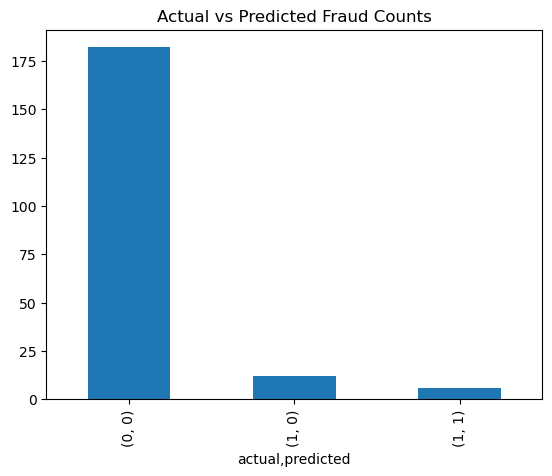

In [11]:
df_res = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
df_res.value_counts().plot(kind='bar')
plt.title("Actual vs Predicted Fraud Counts")
plt.show()

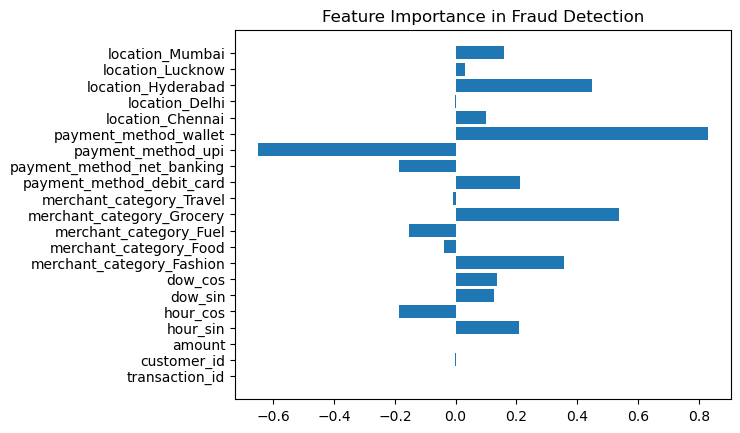

In [12]:

importance = model.coef_[0]
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance in Fraud Detection")
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
# Convert predictions to binary (threshold 0.5)
y_pred_binary = (df_res['predicted'] > 0.5).astype(int)
y_true = df_res['actual'].astype(int)

cm = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[182   0]
 [ 12   6]]


## other algorithms

xgboost

In [15]:

import sys
!{sys.executable} -m pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=182/18,  # Handles imbalance automatically
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)
xgb.fit(X_train, y_train)

Defaulting to user installation because normal site-packages is not writeable


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_pred = xgb.predict(X_test)
df_res = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
# Convert predictions to binary (threshold 0.5)
y_pred_binary = (df_res['predicted'] > 0.5).astype(int)
y_true = df_res['actual'].astype(int)

cm = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[179   3]
 [  9   9]]


random forest

In [17]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=18/200,  # 9% expected fraud rate
    random_state=42,
    n_estimators=200
)

In [18]:
iso.fit(X_test)
y_pred = iso.predict(X_test)
df_res = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
# Convert predictions to binary (threshold 0.5)
y_pred_binary = (df_res['predicted'] > 0.5).astype(int)
y_true = df_res['actual'].astype(int)

cm = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 14 168]
 [  4  14]]


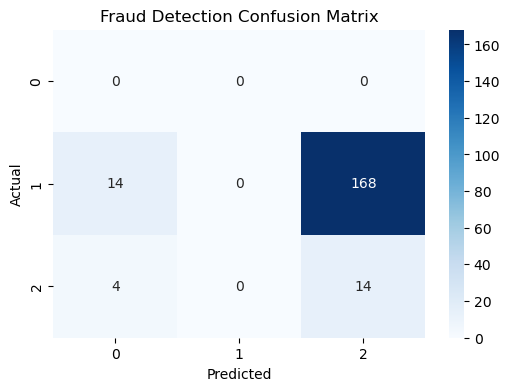

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection Confusion Matrix")

plt.show()

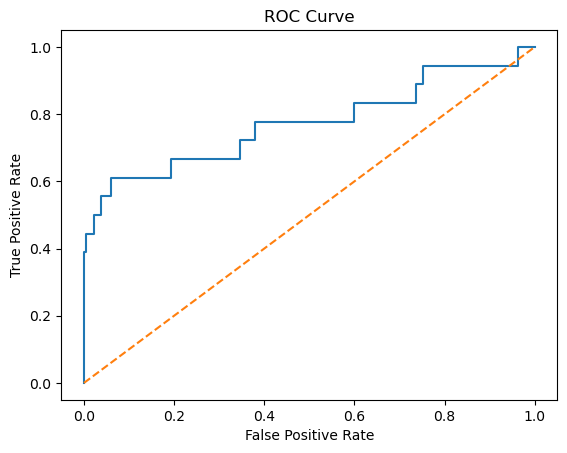

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

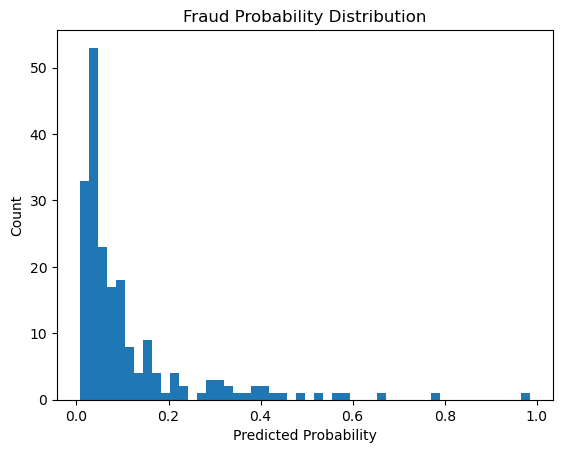

In [21]:
plt.hist(y_prob, bins=50)
plt.title("Fraud Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()